# About Dataset

This is a multivariate type of dataset which means providing or involving a variety of separate mathematical or statistical variables, multivariate numerical data analysis. It is composed of 14 attributes which are age, sex, chest pain type, resting blood pressure, serum cholesterol, fasting blood sugar, resting electrocardiographic results, maximum heart rate achieved, exercise-induced angina, oldpeak — ST depression induced by exercise relative to rest, the slope of the peak exercise ST segment, number of major vessels and Thalassemia. This database includes 76 attributes, but all published studies relate to the use of a subset of 14 of them. The Cleveland database is the only one used by ML researchers to date. One of the major tasks on this dataset is to predict based on the given attributes of a patient that whether that particular person has heart disease or not and other is the experimental task to diagnose and find out various insights from this dataset which could help in understanding the problem more.

# Columns Descriptions

| Column Name | Description | Details / Values |
| :---------- | :---------- | :--------------- |
| `id`        | Unique identifier for each patient. | Integer |
| `age`       | Age of the patient. | In years |
| `origin`    | Place of study/data collection. | Categorical (e.g., Cleveland, Hungary, Switzerland, Long Beach V) |
| `sex`       | Gender of the patient. | `Male` / `Female` (often encoded as `1` for Male, `0` for Female) |
| `cp`        | Chest pain type. | `typical angina`, `atypical angina`, `non-anginal`, `asymptomatic` |
| `trestbps`  | Resting blood pressure. | In mm Hg on admission to the hospital |
| `chol`      | Serum cholesterol level. | In mg/dl |
| `fbs`       | Fasting blood sugar. | `True` if `fasting blood sugar > 120 mg/dl`, `False` otherwise (often encoded as `1` for True, `0` for False) |
| `restecg`   | Resting electrocardiographic results. | `normal`, `stt abnormality`, `lv hypertrophy` |
| `thalach`   | Maximum heart rate achieved. | Integer |
| `exang`     | Exercise-induced angina. | `True` / `False` (often encoded as `1` for Yes, `0` for No) |
| `oldpeak`   | ST depression induced by exercise relative to rest. | Numeric |
| `slope`     | The slope of the peak exercise ST segment. | `upsloping`, `flat`, `downsloping` |
| `ca`        | Number of major vessels colored by fluoroscopy. | Integer from `0` to `3` |
| `thal`      | Thallium stress test results. | `normal`, `fixed defect`, `reversible defect` |
| `num`       | The predicted attribute: presence of heart disease. | `0` = no heart disease, `1` = presence of heart disease (or higher values for severity in some datasets) |

# Importing Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,mean_squared_error,r2_score
import warnings 
warnings.filterwarnings("ignore")

# Loading the dataset

In [2]:
df=pd.read_csv('heart_disease_uci.csv')

> getting overview of data

In [5]:
pd.set_option('display.max_columns', None)  # Show all columns in the DataFrame
pd.set_option('display.max_rows', None)     # Show all rows in the DataFrame

In [6]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


# Exploratory Data Analysis

> Exploring Datatype of each cols

In [4]:
# using df.info() to check the data types of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [5]:
# checking the data shape of dataset
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 920 rows and 16 columns.


In [6]:
# id col
df['id'].min(),df['id'].max()

(np.int64(1), np.int64(920))

In [7]:
df['age'].min(),df['age'].max()

(np.int64(28), np.int64(77))

## output
1. Minimum value of id is 1 and max is 920 means all id are unique.
2. The minimum age is 28 and max is 77.

Text(0.5, 1.0, 'Age Distribution')

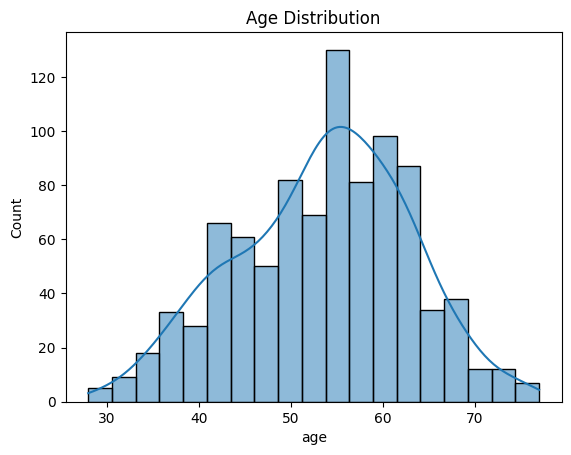

In [9]:
# draw a histogram of the 'age' column to check the distribution of ages
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')